# Anomaly Detection & Alert Grouping — Analysis

This notebook is the visual companion to the CSE636 anomaly-RCA pipeline. It runs the
existing Isolation Forest detector (`src/anomaly_detector.py`) and the existing
rule-based alert grouper (`src/alert_grouper.py`) — unmodified — against one week of
synthetic infrastructure metrics that contains a single injected incident, and produces
three figures showing what got flagged, where the real incident sits relative to a
week of background noise, and why grouping severity is based on how long an event
persists and how many metrics move together, rather than on how extreme any single
metric gets.

No code here re-implements detection or grouping logic — every number and every
timestamp shown below is produced by importing and calling the real functions in
`src/`.

In [1]:
import sys
import os
from pathlib import Path

# This notebook lives in notebooks/, one level below the project root. Jupyter
# (and VS Code's notebook extension) start the kernel's current working
# directory at the notebook's OWN folder -- so Path.cwd() here is .../notebooks,
# and its parent is the project root.
project_root = Path.cwd().parent

# Python only ever auto-adds a script/notebook's OWN directory to sys.path, never
# its parent. Without inserting the project root explicitly, `from src...import`
# below would fail with ModuleNotFoundError, since "src" lives at the project
# root, not inside notebooks/.
sys.path.insert(0, str(project_root))

# The src modules (anomaly_detector.py, alert_grouper.py) open data files using
# paths that are RELATIVE to the process's current working directory, e.g.
# "data/metrics_with_incident.csv". Jupyter's cwd defaults to this notebook's own
# folder (notebooks/), so without chdir those relative paths would resolve to
# notebooks/data/... and fail to find the file. Changing directory once, here,
# makes every relative path later in this notebook -- and inside the imported
# src functions -- resolve exactly as it does when running
# `python -m src.alert_grouper` from the project root.
os.chdir(project_root)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Reusing the existing, unmodified detector and grouper rather than
# re-implementing Isolation Forest or the grouping/severity logic here.
from src.anomaly_detector import load_metrics, detect, DEFAULT_CONTAMINATION_VALUES
from src.alert_grouper import (
    build_alerts,
    group_alerts,
    METRIC_COLUMNS,
    CRITICAL_MIN_DURATION,
    CRITICAL_MIN_METRICS,
    METRICS_PATH,
)

print("Project root:", project_root)
print("Current working directory:", os.getcwd())
print("sys.path[0]:", sys.path[0])

Project root: c:\Users\garre\DevOps\CSE636-anomaly-rca
Current working directory: c:\Users\garre\DevOps\CSE636-anomaly-rca
sys.path[0]: c:\Users\garre\DevOps\CSE636-anomaly-rca


## The dataset

`data/metrics_with_incident.csv` covers **7 days at 1-minute cadence** (7 * 24 * 60 =
10,080 rows). Each row has a `timestamp` and four numeric metrics:

- `cpu_pct` — CPU utilization (%)
- `mem_pct` — memory utilization (%)
- `req_per_sec` — request throughput
- `error_rate` — fraction of requests failing

Somewhere in this week, one sustained incident was injected alongside a scattering of
brief, isolated background anomalies. Nothing below is told where that incident is —
it has to fall out of the detector and grouper's own output.

In [2]:
# Load the metrics exactly the way anomaly_detector.py's own CLI entry point does,
# via the METRICS_PATH constant imported from alert_grouper.py (data/metrics_with_incident.csv)
# rather than re-typing that path as a fresh literal here.
df = load_metrics(METRICS_PATH)

print("Shape:", df.shape)
print("Timestamp range:", df["timestamp"].min(), "to", df["timestamp"].max())

# .head() shows the raw row shape; .describe() over just the four metric columns
# (not is_anomaly) gives a first numeric feel for each metric's normal range.
display(df.head())
display(df[METRIC_COLUMNS].describe())

Shape: (10080, 6)
Timestamp range: 2025-10-01 00:00:00 to 2025-10-07 23:59:00


,timestamp,cpu_pct,mem_pct,req_per_sec,error_rate,is_anomaly
0,2025-10-01 00:00:00,24.23,48.02,175.5,0.184,0
1,2025-10-01 00:01:00,24.31,47.52,174.5,0.199,0
2,2025-10-01 00:02:00,26.18,47.37,146.7,0.243,0
3,2025-10-01 00:03:00,25.71,49.77,204.8,0.179,0
4,2025-10-01 00:04:00,25.92,46.91,190.4,0.168,0


,cpu_pct,mem_pct,req_per_sec,error_rate
count,10080.000000,10080.000000,10080.000000,10080.000000
mean,40.787760,55.059467,299.482470,0.316848
std,12.275944,6.039404,88.225795,0.818342
min,15.290000,40.830000,16.500000,0.000000
25%,30.050000,49.700000,216.900000,0.168000
50%,40.475000,55.040000,299.700000,0.202000
75%,50.550000,60.350000,381.600000,0.236000
max,100.000000,81.760000,590.400000,8.332000


## Running the detector

The detector is run at **contamination = 0.01**, the same conservative setting
`alert_grouper.py` itself uses. Sweeping `anomaly_detector.py`'s own three default
contamination values against the file's ground-truth `is_anomaly` column (a check
`anomaly_detector.py` performs for its own scoring, not repeated here) gives:

| contamination | precision | recall | F1 |
|---|---|---|---|
| 0.01 | 1.00 | 0.45 | 0.62 |
| 0.04 | 0.55 | 0.99 | **0.70 (highest)** |
| 0.10 | 0.22 | 0.99 | 0.36 |

0.04 is the F1-optimal setting -- the right choice if the goal is to score the
detector against ground truth. 0.01 trades recall for precision instead: it flags only
the minutes the model is most confident about, at the cost of missing the softer onset
and recovery edges of a real incident. That's exactly the tradeoff wanted here --
this notebook (like `alert_grouper.py`) is not scoring against ground truth, it's
demonstrating grouping, and a smaller, cleaner set of flagged minutes makes the
"one real incident vs. scattered noise" story easier to see.

In [3]:
# Same conservative contamination alert_grouper.py uses -- see markdown above for why.
contamination = DEFAULT_CONTAMINATION_VALUES[0]
predicted = detect(df, contamination)
flags = predicted["predicted_anomaly"] == 1

# Baselines are computed from NON-flagged rows only. If the flagged (anomalous) rows
# were left in, they would pull the mean and inflate the standard deviation -- and a
# metric can never look like an outlier relative to a baseline that already contains
# the outliers. This mirrors the exact reasoning in alert_grouper.py's own main().
normal_rows = predicted.loc[~flags]
baselines = {col: (normal_rows[col].mean(), normal_rows[col].std()) for col in METRIC_COLUMNS}

# build_alerts turns each flagged row into one raw "ticket"; group_alerts collapses
# nearby tickets into incidents and scores each one's severity. Neither function is
# reimplemented here -- both are the real functions from alert_grouper.py.
alerts = build_alerts(predicted, flags)
groups = group_alerts(alerts, baselines)

critical_groups = [g for g in groups if g["severity"] == "critical"]

print(f"Raw alerts:      {len(alerts)}")
print(f"Groups:          {len(groups)}")
print(f"Critical groups: {len(critical_groups)}")
print()
for g in critical_groups:
    print(g)

# Fail loud (matching this repo's existing convention, e.g. generate_logs.py) rather
# than silently producing an empty/misleading zoom plot later if this ever changes.
assert critical_groups, "No critical groups found -- cannot derive a zoom window."


Raw alerts:      101
Groups:          76
Critical groups: 1

{'group_id': 53, 'start_time': '2025-10-05T14:10:00', 'end_time': '2025-10-05T14:33:00', 'duration_minutes': 23.0, 'alert_count': 24, 'max_deviating_metrics': 4, 'peak_cpu_pct': 97.32, 'peak_mem_pct': 81.76, 'peak_req_per_sec': 215.4, 'peak_error_rate': 8.332, 'severity': 'critical'}


## Figure 1: week overview

One row per metric, spanning the full week. The thin line is the raw signal; the red
scatter points mark exactly which minutes the detector flagged; the orange shaded
band marks every group classified `critical`. This is the "big picture" view --
one real, sustained incident should visually stand out against a week of much
smaller, scattered flags.

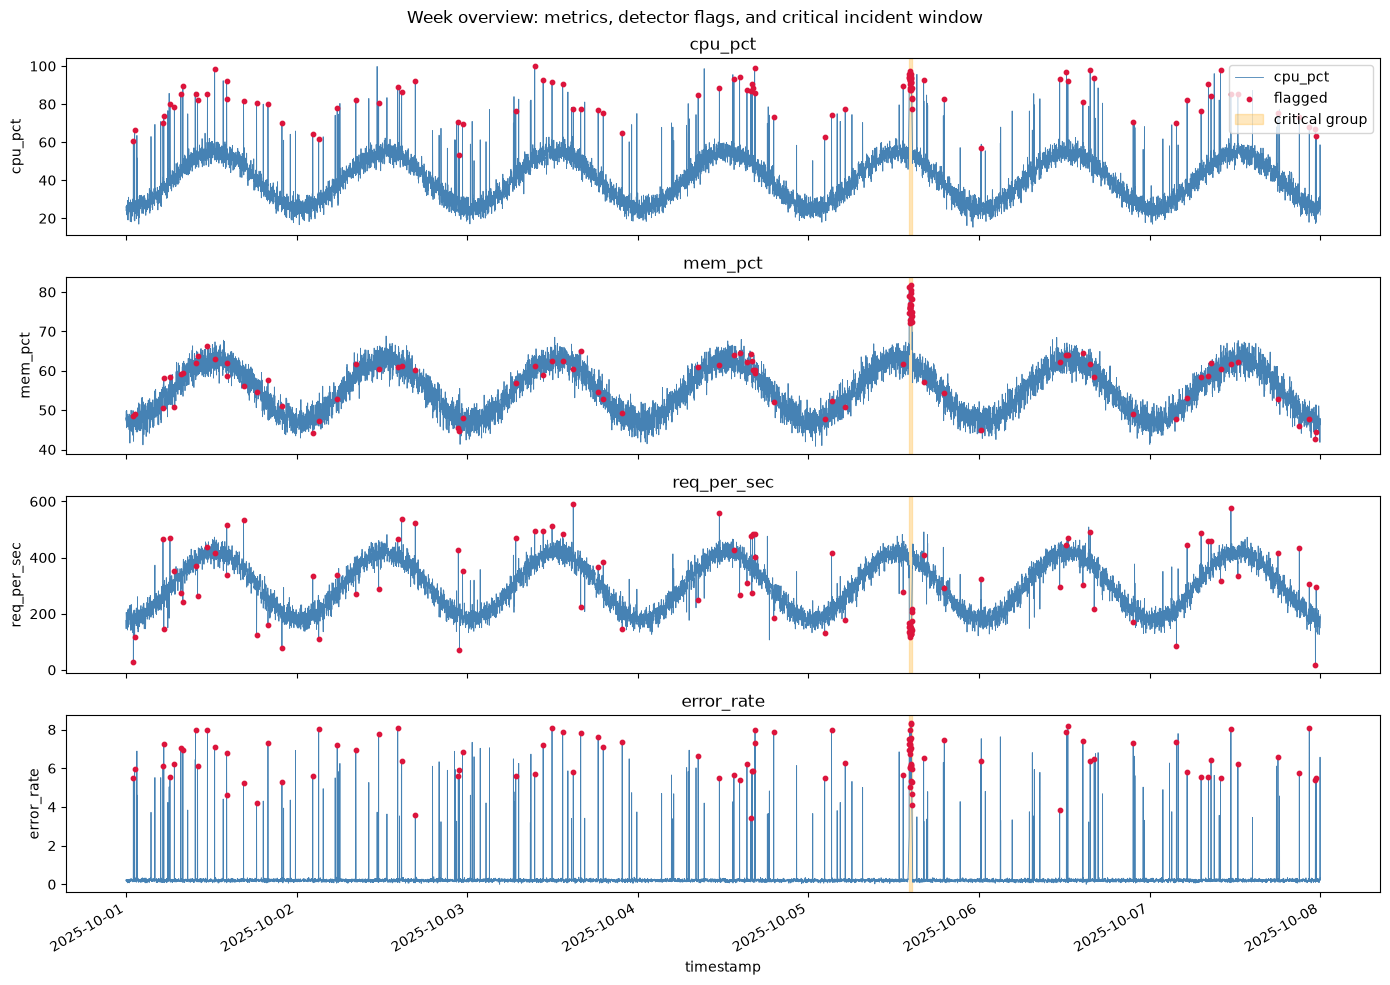

In [4]:
fig1, axes1 = plt.subplots(len(METRIC_COLUMNS), 1, figsize=(14, 10), sharex=True)

flagged_df = predicted.loc[flags]

for ax, col in zip(axes1, METRIC_COLUMNS):
    # Thin line = the full week's raw signal for this one metric.
    ax.plot(predicted["timestamp"], predicted[col], linewidth=0.6, color="steelblue", label=col)
    # Scatter overlay in a visually distinct color marks exactly which minutes the
    # detector flagged as anomalous -- without this, there'd be no way to see WHERE
    # in the line the detector actually fired.
    ax.scatter(flagged_df["timestamp"], flagged_df[col], color="crimson", s=10, zorder=3, label="flagged")
    # Shade every critical group's span (there happens to be exactly one today, but
    # this loops over however many exist) so the one real incident is visually
    # obvious against the rest of the week.
    for g in critical_groups:
        ax.axvspan(pd.Timestamp(g["start_time"]), pd.Timestamp(g["end_time"]), color="orange", alpha=0.25, label="critical group")
    ax.set_title(col)
    ax.set_ylabel(col)

# Only the top subplot's legend is shown -- each subplot's own line/scatter/span
# already carries the same three labels, so one legend is enough to explain all four rows.
axes1[0].legend(loc="upper right")
axes1[-1].set_xlabel("timestamp")
fig1.suptitle("Week overview: metrics, detector flags, and critical incident window")
fig1.autofmt_xdate()  # angles the date ticks so a week's worth of timestamps stay readable
fig1.tight_layout()

Path("output").mkdir(exist_ok=True)  # defensive -- output/ already exists in this repo, but this keeps the notebook portable
fig1.savefig("output/fig1_week_overview.png", dpi=120)
plt.show()

## Figure 2: incident zoom

The full week compresses the incident into a thin sliver. This figure zooms into just
the critical group(s), **padded by 60 minutes on each side** so the plot shows
baseline behavior before onset, the climb into the incident, its peak, and the
recovery back to baseline afterward.

The window is **derived from the critical group's own detected start/end**, not
hardcoded -- `zoom_start`/`zoom_end` below are computed from whatever `group_alerts()`
actually returned in the cell above. If the data, detector, or thresholds ever
changed, this window would move with them automatically.

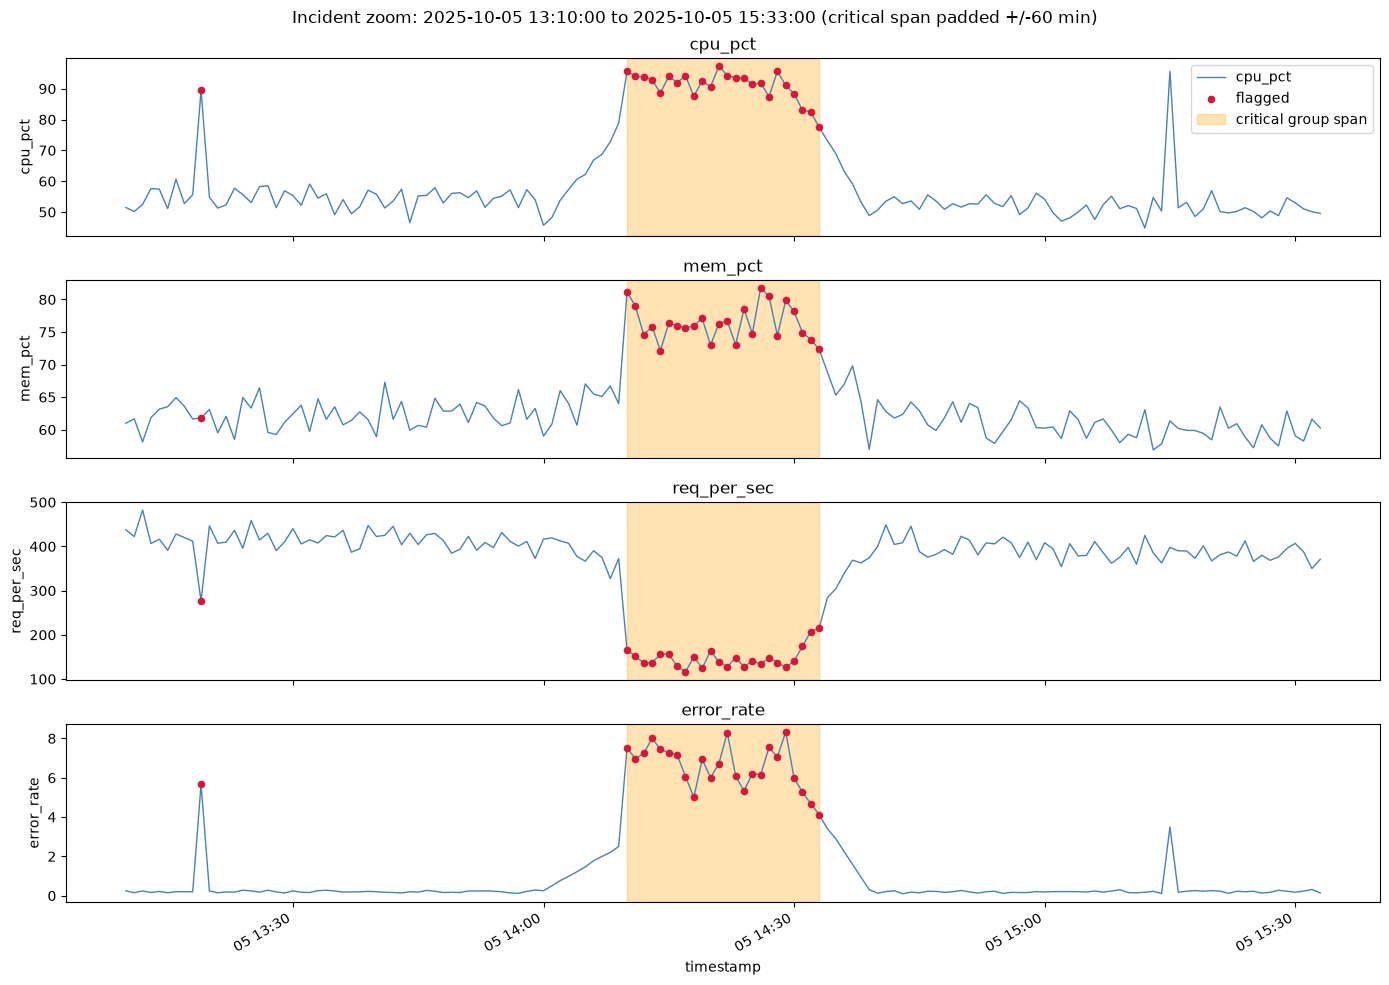

In [5]:
# Derive the zoom window from the critical group(s) themselves -- across ALL
# critical groups (there's one today), not a hardcoded timestamp -- padded by 60
# minutes on each side so onset and recovery are visible, not just the flagged core.
pad = pd.Timedelta(minutes=60)
zoom_start = min(pd.Timestamp(g["start_time"]) for g in critical_groups) - pad
zoom_end = max(pd.Timestamp(g["end_time"]) for g in critical_groups) + pad

zoom_mask = (predicted["timestamp"] >= zoom_start) & (predicted["timestamp"] <= zoom_end)
zoom_df = predicted.loc[zoom_mask]
zoom_flagged = zoom_df.loc[zoom_df["predicted_anomaly"] == 1]

fig2, axes2 = plt.subplots(len(METRIC_COLUMNS), 1, figsize=(14, 10), sharex=True)

for ax, col in zip(axes2, METRIC_COLUMNS):
    ax.plot(zoom_df["timestamp"], zoom_df[col], linewidth=1.0, color="steelblue", label=col)
    ax.scatter(zoom_flagged["timestamp"], zoom_flagged[col], color="crimson", s=20, zorder=3, label="flagged")
    # Shade each critical group's EXACT detected span (narrower than the padded
    # window plotted here), so the contrast between "padding" and "actual incident"
    # is visible directly on the plot.
    for g in critical_groups:
        ax.axvspan(pd.Timestamp(g["start_time"]), pd.Timestamp(g["end_time"]), color="orange", alpha=0.3, label="critical group span")
    ax.set_title(col)
    ax.set_ylabel(col)

axes2[0].legend(loc="upper right")
axes2[-1].set_xlabel("timestamp")
fig2.suptitle(f"Incident zoom: {zoom_start} to {zoom_end} (critical span padded +/-60 min)")
fig2.autofmt_xdate()
fig2.tight_layout()
fig2.savefig("output/fig2_incident_zoom.png", dpi=120)
plt.show()

## Figure 3: severity is about persistence and breadth, not magnitude

Every group from Figure 1/2's data is plotted here as one point: how long it lasted
(x) against how many metrics were simultaneously deviating at its worst moment (y).
If magnitude alone separated the real incident from background noise, the critical
group would simply be the point furthest from the origin. It isn't -- several
single-minute background blips reach the same breadth (4 of 4 metrics deviating) as
the incident's own worst minute. What actually sets the critical group apart is that
it sits far to the **right**: it kept failing the deviation check for many consecutive
minutes, not just one.

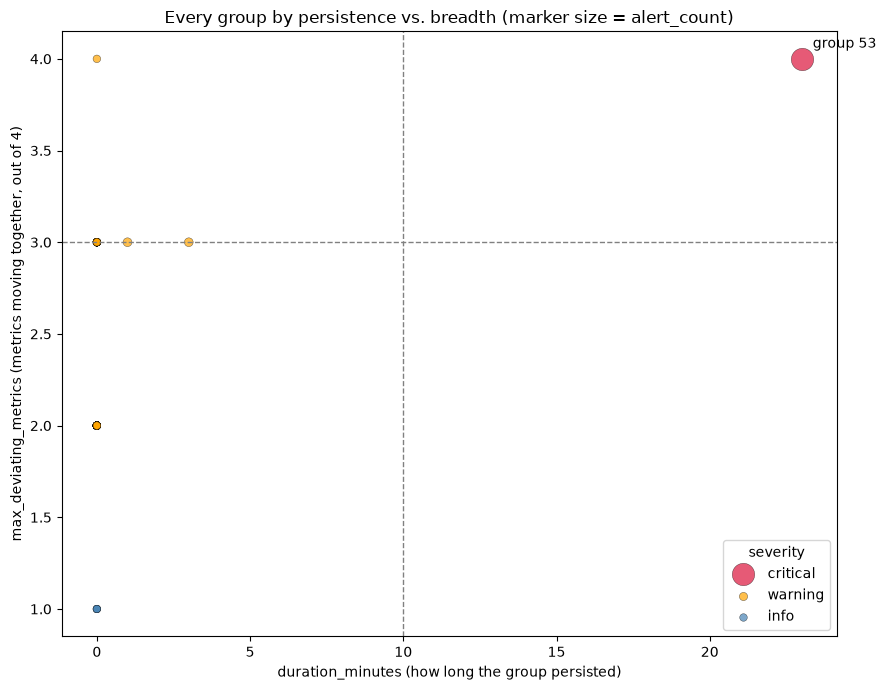

In [6]:
severity_colors = {"critical": "crimson", "warning": "orange", "info": "steelblue"}

fig3, ax3 = plt.subplots(figsize=(9, 7))

for severity, color in severity_colors.items():
    subset = [g for g in groups if g["severity"] == severity]
    if not subset:
        continue
    xs = [g["duration_minutes"] for g in subset]
    ys = [g["max_deviating_metrics"] for g in subset]
    # Marker area scales with alert_count, so a group built from many raw alerts
    # (a longer, more heavily-flagged event) visually stands out from a group
    # built from just one or two.
    sizes = [20 + g["alert_count"] * 10 for g in subset]
    ax3.scatter(xs, ys, s=sizes, color=color, alpha=0.7, label=severity, edgecolors="black", linewidths=0.3)

# Dashed lines mark the EXACT boundary classify_severity() uses for "critical":
# duration >= CRITICAL_MIN_DURATION AND max_deviating_metrics >= CRITICAL_MIN_METRICS.
# Only points in the upper-right quadrant (right of the vertical line AND above the
# horizontal line) can ever be classified critical, regardless of how far right or
# how high up they are individually.
ax3.axvline(CRITICAL_MIN_DURATION, color="gray", linestyle="--", linewidth=1)
ax3.axhline(CRITICAL_MIN_METRICS, color="gray", linestyle="--", linewidth=1)

for g in critical_groups:
    ax3.annotate(f"group {g['group_id']}", (g["duration_minutes"], g["max_deviating_metrics"]),
                 textcoords="offset points", xytext=(8, 8))

# x-axis: how long the group persisted, in minutes (the "duration" half of the rule).
ax3.set_xlabel("duration_minutes (how long the group persisted)")
# y-axis: how many of the 4 metrics were simultaneously > DEVIATION_SIGMA away from
# baseline at the group's worst moment (the "breadth" half of the rule).
ax3.set_ylabel("max_deviating_metrics (metrics moving together, out of 4)")
ax3.set_title("Every group by persistence vs. breadth (marker size = alert_count)")
ax3.legend(title="severity")
fig3.tight_layout()
fig3.savefig("output/fig3_group_severity.png", dpi=120)
plt.show()

## Closing observations

- **The detected critical span is narrower than what Figure 2 visibly shows.** The
  orange band in Figure 2 covers only the minutes the detector was confident enough
  to flag at contamination 0.01, but the line plots on either side of that band
  clearly still show a gradual climb before it starts and a gradual decay after it
  ends -- onset and recovery phases whose values are more extreme than baseline but
  not extreme enough to clear this conservative detector's threshold. A less
  conservative contamination (e.g. 0.04, the F1-optimal setting from earlier) would
  catch more of that ramp, at the cost of also flagging more background noise.

- **Magnitude alone cannot separate the incident from noise.** As Figure 3 shows,
  at least one single-minute background group reaches `max_deviating_metrics = 4` --
  the same breadth as the critical group's own worst minute. If severity were based
  on magnitude/breadth alone, that isolated blip would be indistinguishable from a
  real incident. It's the horizontal position in Figure 3 -- duration -- that tells
  them apart.

- **The reduction ratio is modest: 101 raw alerts collapse into 76 groups, only
  about 1.3x.** That's because `classify_severity()`'s warning tier is an OR
  condition (`duration >= 3 OR max_deviating_metrics >= 2`), so most background
  blips clear it as isolated single minutes rather than being left at `info`. A
  stricter warning rule -- for example requiring both conditions (AND instead of
  OR), or raising `WARNING_MIN_METRICS` -- would push more of these blips down to
  `info` and shrink the warning tier further, at the cost of being slower to flag a
  genuinely emerging (but not yet critical) event.